# Palace CPW Simulation — Lumped Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on an asymmetric CPW (coplanar waveguide) structure.

**Requirements:**

- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

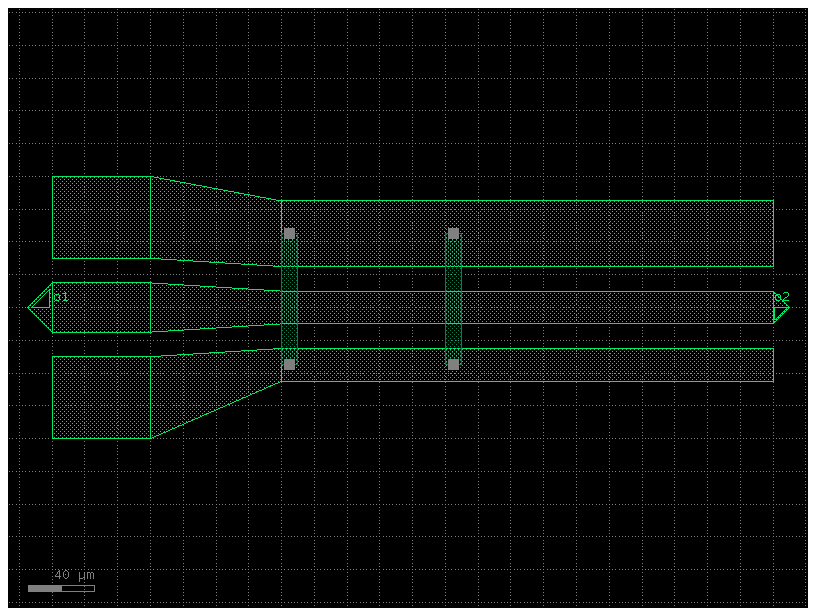

In [24]:
"""Asymmetric CPW with launch-pad discontinuity and slotline-killing airbridges.

Finite-ground CPW with unequal ground-plane widths: the gap W is held
constant top/bottom, and only the ground-plane widths (top vs bottom)
differ. That width asymmetry is what allows a slotline-like (odd) mode
to exist and propagate; airbridges periodically strap the two ground
planes together to suppress it.

Ports:
  - o1: lumped port, CPW mode only (add_cpw_port references both
    grounds together at the port plane, enforcing pure CPW excitation).
  - o2: wave port with a 2-mode eigenmode expansion.
      mode=1 -> even/CPW-like mode  -> S(mode1,port1) = CPW mode received
      mode=2 -> odd/slotline-like mode -> S(mode2,port1) = slotline mode
                excited by the asymmetry and surviving past the airbridges

Construction notes:
  - Layers follow the generic PDK stack/connectivity
    (M1 -- VIA1 -- M2 -- VIA2 -- M3):
      METAL_LAYER  = M1   (pads, tapers, line, grounds)
      BRIDGE_LAYER = M2   (airbridge strap, one level above METAL_LAYER)
      VIA_LAYER    = VIA1 (connects M1 <-> M2; not VIAC, which only
                            connects doped silicon layers to M1)
  - gap_line should equal gap_pad so both ground tapers stay parallel to
    the signal taper; only the ground plane widths differ.
"""

import gdsfactory as gf
from gdsfactory.gpdk import LAYER

gf.gpdk.PDK.activate()

METAL_LAYER = LAYER.M1
BRIDGE_LAYER = LAYER.M2
VIA_LAYER = LAYER.VIA1


@gf.cell
def asymmetric_cpw_with_airbridges(
    # launch pad / input discontinuity (symmetric)
    pad_length: float = 60,
    s_pad_width: float = 30,
    g_pad_width: float = 50,
    gap_pad: float = 15,
    taper_length: float = 80,
    # main line (asymmetric ground widths, constant gap so tapers stay parallel)
    line_length: float = 300,
    s_width: float = 20,
    g_width_top: float = 40,
    g_width_bot: float = 20,
    gap_line: float = 15,  # keep equal to gap_pad -> parallel tapers
    # airbridges
    num_bridges: int = 2,
    bridge_width: float = 10,
    bridge_spacing: float = 100,
    bridge_start_offset: float = 5,
    via_margin: float = 4,
    metal_layer=METAL_LAYER,
    bridge_layer=BRIDGE_LAYER,
    via_layer=VIA_LAYER,
) -> gf.Component:
    """Launch pad -> taper -> asymmetric-width CPW line with airbridges -> o2."""
    c = gf.Component()

    if gap_line != gap_pad:
        print("Warning: gap_line != gap_pad. The taper gaps will NOT be parallel.")
    if g_width_top >= g_pad_width or g_width_bot >= g_pad_width:
        raise ValueError(
            f"g_width_top ({g_width_top}) and g_width_bot ({g_width_bot}) "
            f"must both be < g_pad_width ({g_pad_width}), or that ground "
            "won't visibly neck down in width along the taper."
        )

    # Signal (center) trace
    pad_pts = [
        (-pad_length, -s_pad_width / 2),
        (-pad_length, s_pad_width / 2),
        (0, s_pad_width / 2),
        (0, -s_pad_width / 2),
    ]
    c.add_polygon(pad_pts, layer=metal_layer)

    s_taper_pts = [
        (0, s_pad_width / 2),
        (taper_length, s_width / 2),
        (taper_length, -s_width / 2),
        (0, -s_pad_width / 2),
    ]
    c.add_polygon(s_taper_pts, layer=metal_layer)

    line_pts = [
        (taper_length, -s_width / 2),
        (taper_length, s_width / 2),
        (taper_length + line_length, s_width / 2),
        (taper_length + line_length, -s_width / 2),
    ]
    c.add_polygon(line_pts, layer=metal_layer)

    # Ground traces (top & bottom), asymmetric in widths only
    def draw_ground(is_top: bool):
        sign = 1 if is_top else -1
        g_width_line = g_width_top if is_top else g_width_bot

        y_pad_inner = sign * (s_pad_width / 2 + gap_pad)
        y_pad_outer = sign * (s_pad_width / 2 + gap_pad + g_pad_width)
        y_line_inner = sign * (s_width / 2 + gap_line)
        y_line_outer = sign * (s_width / 2 + gap_line + g_width_line)

        pad_pts = [
            (-pad_length, y_pad_inner),
            (-pad_length, y_pad_outer),
            (0, y_pad_outer),
            (0, y_pad_inner),
        ]
        c.add_polygon(pad_pts, layer=metal_layer)

        taper_pts = [
            (0, y_pad_inner),
            (0, y_pad_outer),
            (taper_length, y_line_outer),
            (taper_length, y_line_inner),
        ]
        c.add_polygon(taper_pts, layer=metal_layer)

        line_pts = [
            (taper_length, y_line_inner),
            (taper_length, y_line_outer),
            (taper_length + line_length, y_line_outer),
            (taper_length + line_length, y_line_inner),
        ]
        c.add_polygon(line_pts, layer=metal_layer)

        return sign * (s_width / 2 + gap_line + g_width_line / 2)

    y_center_top = draw_ground(is_top=True)
    y_center_bot = draw_ground(is_top=False)

    # Airbridges: strap G_top to G_bottom across signal + both gaps
    bridge_start_x = taper_length + bridge_start_offset
    for i in range(num_bridges):
        bx = bridge_start_x + i * bridge_spacing

        strap_pts = [
            (bx - bridge_width / 2, y_center_bot),
            (bx - bridge_width / 2, y_center_top),
            (bx + bridge_width / 2, y_center_top),
            (bx + bridge_width / 2, y_center_bot),
        ]
        c.add_polygon(strap_pts, layer=bridge_layer)

        via_size_top = min(bridge_width, g_width_top) - via_margin
        via_top_pts = [
            (bx - via_size_top / 2, y_center_top - via_size_top / 2),
            (bx - via_size_top / 2, y_center_top + via_size_top / 2),
            (bx + via_size_top / 2, y_center_top + via_size_top / 2),
            (bx + via_size_top / 2, y_center_top - via_size_top / 2),
        ]
        c.add_polygon(via_top_pts, layer=via_layer)

        via_size_bot = min(bridge_width, g_width_bot) - via_margin
        via_bot_pts = [
            (bx - via_size_bot / 2, y_center_bot - via_size_bot / 2),
            (bx - via_size_bot / 2, y_center_bot + via_size_bot / 2),
            (bx + via_size_bot / 2, y_center_bot + via_size_bot / 2),
            (bx + via_size_bot / 2, y_center_bot - via_size_bot / 2),
        ]
        c.add_polygon(via_bot_pts, layer=via_layer)

    # Ports
    c.add_port(
        name="o1",
        center=(-pad_length, 0),
        width=s_pad_width,
        orientation=180,
        port_type="electrical",
        layer=metal_layer,
    )
    c.add_port(
        name="o2",
        center=(taper_length + line_length, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=metal_layer,
    )
    return c


port_kwargs = dict(s_pad_width=30, gap_pad=15)
c = asymmetric_cpw_with_airbridges(**port_kwargs)
cc = c.copy()
cc.draw_ports()
cc.plot()

### Configure and run simulation with DrivenSim

In [25]:
from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-asymmetric-cpw")

# Set the component geometry
sim.set_geometry(c)

# Configure layer stack from active PDK
stack = get_stack()
sim.set_stack(stack)
sim.set_airbox(margin_x=0.0, margin_y=50.0, z_above=100.0, z_below=100.0)

# o1: lumped port at the symmetric launch pad -> excites CPW mode only,
sim.add_cpw_port(
    "o1",
    layer="metal1",
    s_width=port_kwargs["s_pad_width"],
    gap_width=port_kwargs["gap_pad"],
    excited=True,
)

# o2: 2-mode wave port at the asymmetric line's own cross-section
sim.add_wave_port(
    "o2", layer="metal1", max_size=True, mode=1, excited=False
)  # CPW mode

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [26]:
sim.mesh(preset="default", refined_mesh_size=2.0, max_mesh_size=40)

Mesh Summary
Dimensions: 440.0 x 360.0 x 208.6 µm
Nodes:      23,661
Elements:   170,936
Tetrahedra: 122,972
Edge length: 0.12 - 83.07 µm
Quality:    0.538 (min: 0.000)
SICN:       0.574 (all valid)
----------------------------------------
Volumes (4):
  - via1 [1]
  - sio2 [2]
  - passive [3]
  - air [4]
Surfaces (14):
  - metal1_xy [5]
  - metal1_z [6]
  - metal2_xy [7]
  - metal2_z [8]
  - P1_E0 [9]
  - P1_E1 [10]
  - P2 [11]
  - sio2__via1 [12]
  - sio2__None [13]
  - air__sio2 [14]
  - passive__sio2 [15]
  - passive__None [16]
  - air__passive [17]
  - air__None [18]
----------------------------------------
Mesh:   palace-sim-asymmetric-cpw/palace.msh

In [27]:
sim.plot_mesh(show_groups=["metal", "P", "via"])

Widget(value='<iframe src="http://localhost:37947/index.html?ui=P_0x7b46e17f0bc0_6&reconnect=auto" class="pyvi…

In [28]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:37947/index.html?ui=P_0x7b46ce5212b0_7&reconnect=auto" class="pyvi…

### Run simulation

In [31]:
results = sim.run_local(palace_executable="~/palace/build/bin/palace")
# results = sim.run()

Running Palace simulation in palace-sim-asymmetric-cpw directly
Command: /home/delfi/palace/build/bin/palace -np 14 config.json
Processes: 14
>> /usr/local/bin/mpirun -n 14 /home/delfi/palace/build/bin/palace-x86_64.bin config.json
_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/
--> Warning!
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.16.1-106-g61b1506e
Running with 14 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked
MFEM abort: (r,c,f) = (4727,4894,17743)
 ... in function: int mfem::STable3D::operator()(int, int, int) const
 ... in file: /home/delfi/palace/build/extern/mfem/general/stable3d.cpp:112
--------------------------------------------------------------------------
MPI_ABORT was invoked on rank 0 in communicator MP

RuntimeError: Palace simulation failed with return code 1

Output (tail):
>> /usr/local/bin/mpirun -n 14 /home/delfi/palace/build/bin/palace-x86_64.bin config.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


[38;2;255;255;000m--> Warning![0m
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.16.1-106-g61b1506e
Running with 14 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked



MFEM abort: (r,c,f) = (4727,4894,17743)
 ... in function: int mfem::STable3D::operator()(int, int, int) const
 ... in file: /home/delfi/palace/build/extern/mfem/general/stable3d.cpp:112

--------------------------------------------------------------------------
MPI_ABORT was invoked on rank 0 in communicator MPI_COMM_WORLD
  Proc: [[18357,1],0]
  E

### Plot S-parameters

In [ ]:
results.plot_interactive()

In [ ]:
results.plot_interactive(phase=True)